## **Problem Statement** <br>
A Credit Risk Dataset has been attached from Kaggle. You need to predict the Loan Status using the Decision Tree Algorithm. The following deliverables are required from you:
1. An enhanced EDA on the dataset, and explaining what each EDA technique depicts with respect to the dataset.
2. You also need to explain the types of accuracy you are getting from the respective model, along with Precision, Recall and F1-Scores.
3. A detailed report is to be generated for the results, and any specific observations are to be mentioned.
Upload your .ipynb file (code along with output, comments expected) as well as a PDF (for the result discussions and observations).


## **Data Description** <br>

### **Dataset Context:** <br>


> The dataset contains a mix of demographic information (e.g., age, income),financial behavior (e.g., credit history, debt-to-income ratio), and loan-specific details (e.g., loan amount, interest rate).


### **Dataset Overview:** <br>

> **Source:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset/ <br> **Number of Instances (Rows):** 32,581<br>**Number of Attributes (Columns):** 12<br>**Target Variable:** loan_status

### **Feature Information:** <br>

$$
\begin{array}{|c|c|c|}
\hline
\textbf{Column Name} & \textbf{Description} & \textbf{Data Type} \\
\hline
\text{loan_status} & \text{The status of the loan} & \text{Numerical (Binary: 0/1)} \\
\hline
\text{person_age} & \text{Age of the loan applicant} & \text{Numerical (Integer)} \\
\hline
\text{person_income} & \text{Annual income of the applicant (USD)} & \text{Numerical (Continuous)} \\
\hline
\text{person_home_ownership} & \text{Housing status: Rent, Own, Mortgage} & \text{Categorical} \\
\hline
\text{person_emp_length} & \text{Employment length (years)} & \text{Numerical (Continuous)} \\
\hline
\text{loan_intent} & \text{Purpose: Education, Medical, Venture, etc.} & \text{Categorical} \\
\hline
\text{loan_grade} & \text{Loan grade: A, B, C, D, E, F, G} & \text{Categorical (Ordinal)} \\
\hline
\text{loan_amnt} & \text{Loan amount (USD)} & \text{Numerical (Continuous)} \\
\hline
\text{loan_int_rate} & \text{Interest rate (%)} & \text{Numerical (Continuous)} \\
\hline
\text{loan_percent_income} & \text{Loan amount as % of income} & \text{Numerical (Continuous)} \\
\hline
\text{cb_person_default_on_file} & \text{Historical default: Y/N} & \text{Categorical (Binary)} \\
\hline
\text{cb_person_cred_hist_length} & \text{Credit history length (years)} & \text{Numerical (Integer)} \\
\hline
\end{array}
$$
<br>
### **Target variable:**
> **Name:** loan_status <br> **Description:** This variable indicates the final status of a loan, specifically whether the borrower has defaulted.<br> **Values:**
$$
\begin{array}{|c|c|}
\hline
\textbf{Value} & \textbf{Description} \\
\hline
0 & Non-Defaulted(Low Risk)\\
\hline
1 & Defaulted(High Risk) \\
\hline  
\end{array}
$$




## **Source code**

###**Importing Libraries:**

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd


# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as ex

# Preprocessing and Decision Tree Model
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report


# Other Libraries
import os
import io
import requests
import warnings
warnings.filterwarnings("ignore")

###**Importing DataSet:**

In [2]:
df = pd.read_csv("/content/credit_risk_dataset.csv", skipinitialspace = True)

In [3]:
#Deep copy the original dataset
df_copy = df.copy(deep=True)

###**Exploratory Data Analysis (EDA):**

####**Basic Information Gathering:**

In [4]:
# Display the dataset
df_copy

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [5]:
# Concise summery of the dataset
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Shape of the dataset
df_copy.shape

(32581, 12)

In [7]:
# Size of the dataset --> no. of Columns * no. of rows
df_copy.size

390972

#### **About Target Variable:**

1.   Description
2.   The value count(in %)
3.   Pie chart
4.   Bar chart



In [8]:
df_copy['loan_status'].describe().T

,loan_status
count,32581.000000
mean,0.218164
std,0.413006
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [9]:
df_copy['loan_status'].value_counts() / len(df) * 100

,count
loan_status,
0,78.183604
1,21.816396


In [10]:
ex.pie(df_copy,names='loan_status',title='Propotion Of Loan Status',hole=0.33)

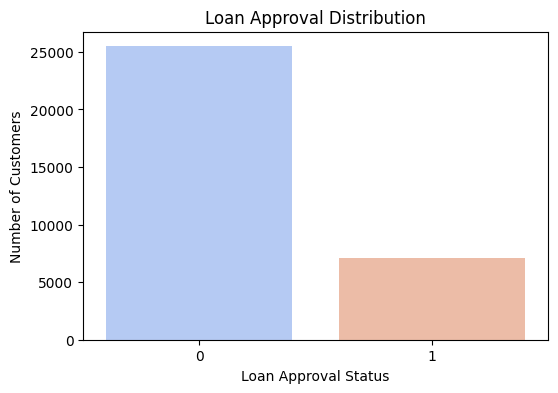

In [11]:
# Plotting the distribution of loan approval status
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df, palette="coolwarm")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Customers")
plt.show()

#### **Segregating dataset:**

*   Segregating Numerical Variables from Categorical Variables.



In [12]:
df_num = df_copy.select_dtypes(include='number') # Shape : 32581 X 8
df_cat = df_copy.select_dtypes(include=['object','category']) # Shape: 32581 X 8

#### **Operation on numerical data:**

1.   Descriptive statistics on numerical values
2.   Histogram plot on Loan_amount
3.   Correlation matrix



In [13]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


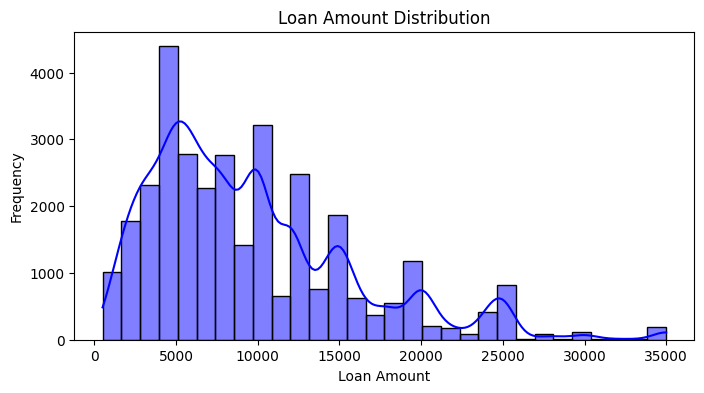

In [14]:
# Histogram to plot the loan amount
plt.figure(figsize = (8,4))
sns.histplot(df['loan_amnt'], bins=30, kde=True, color="blue")
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


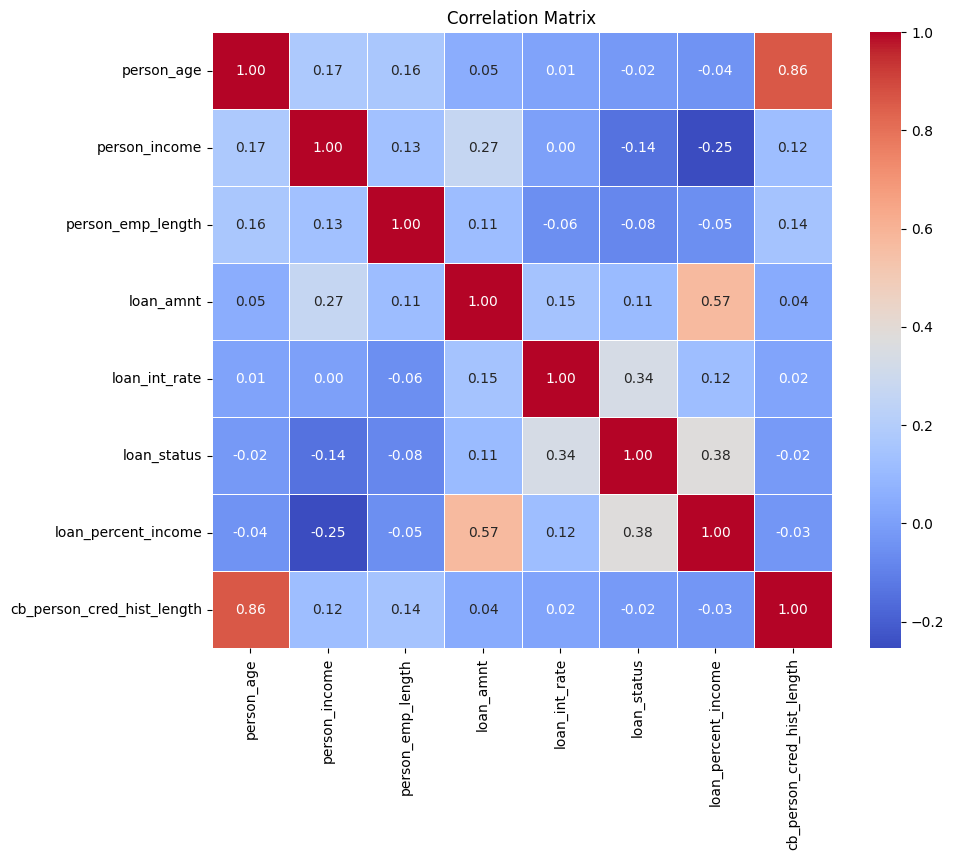

In [15]:
# Create the correlation matrix
corr_matrix = df_num.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

#### **Missing Values and duplicate detection:**

In [16]:
# Display all the missing/null values
df_copy.isna().sum().sort_values(ascending = False)


,0
loan_int_rate,3116
person_emp_length,895
person_income,0
person_age,0
person_home_ownership,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_status,0
loan_percent_income,0


In [17]:
# Display duplicate rows
df_copy.duplicated().sum()

np.int64(165)

#### **Outlier Detection:**


> The column person_age has a maximum value of 144(years). Same idea for column person_emp_year where maximum value is 123 years both cases are impossible and obvious an outlier.



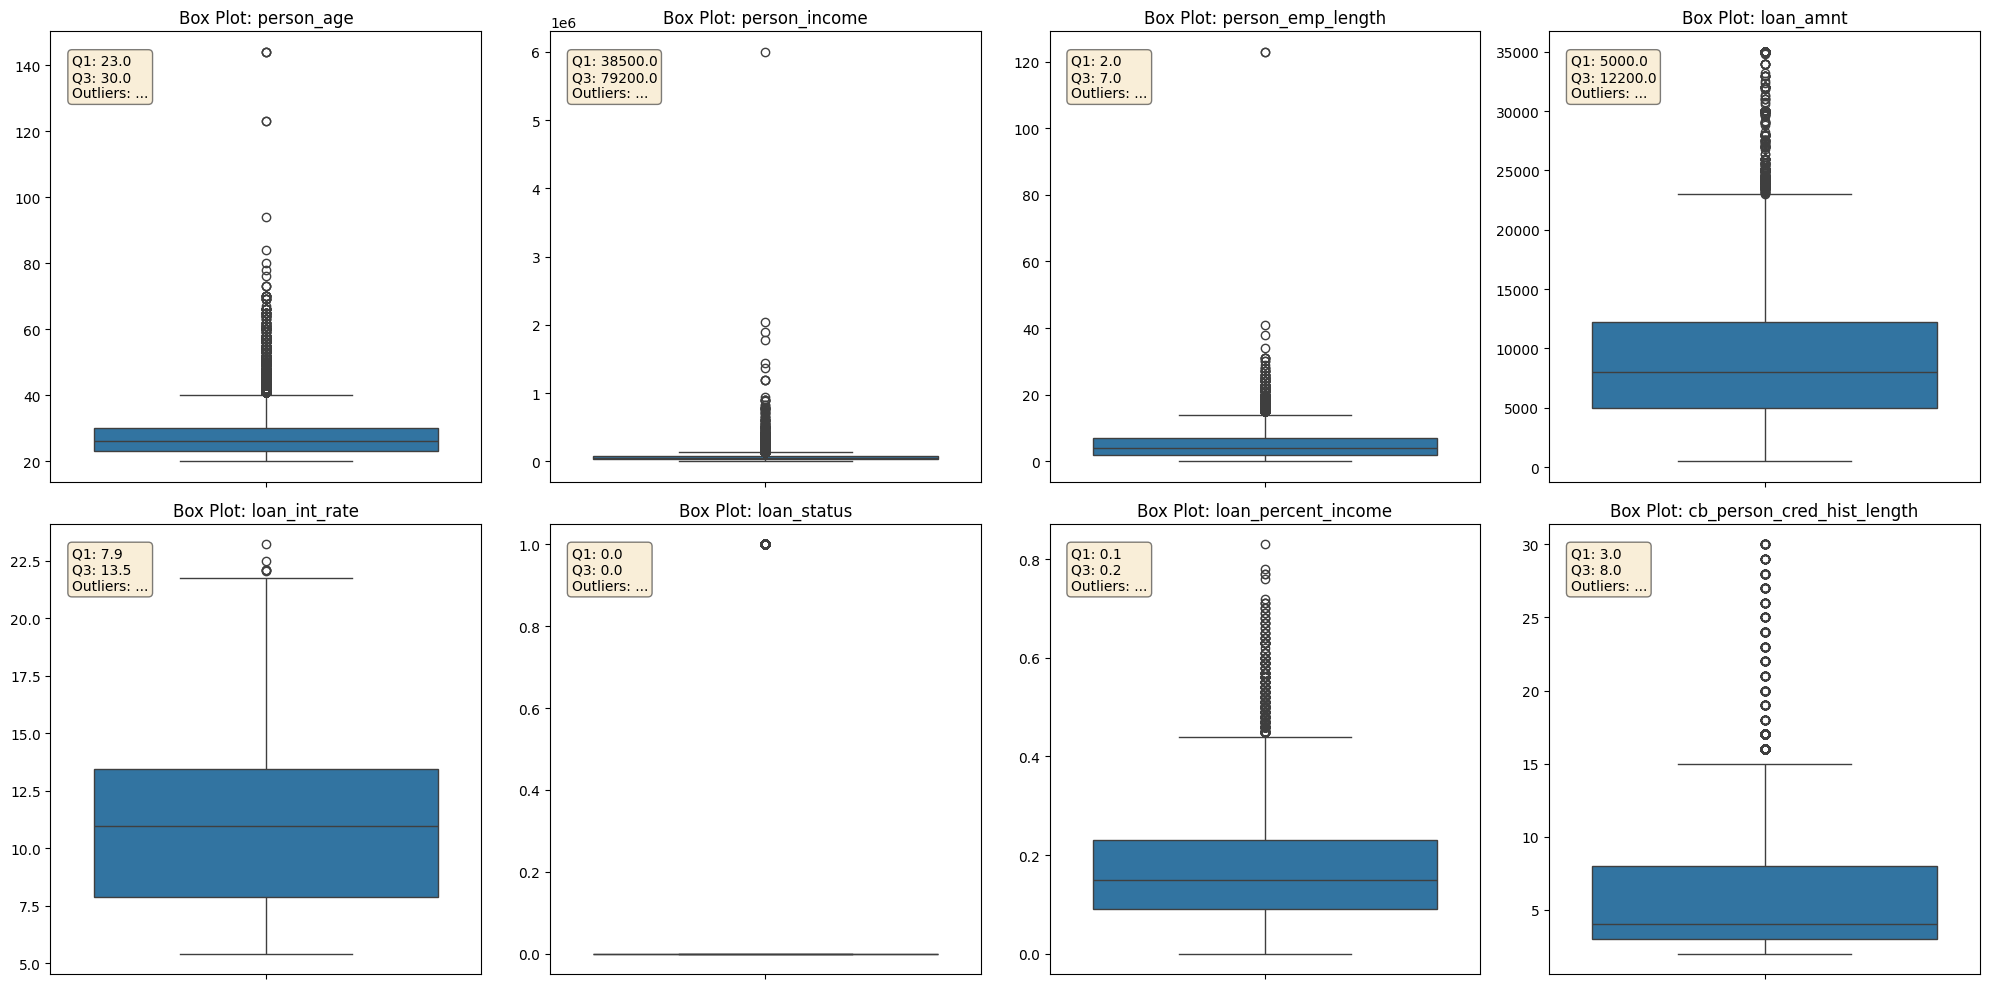

In [18]:
# Using seaborn for better aesthetics
numerical_cols = df_num.columns

# Calculate grid size
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Box Plot: {col}')
        axes[i].set_ylabel('')

        # Add value annotations
        stats = df_num[col].describe()
        axes[i].text(0.05, 0.95, f"Q1: {stats['25%']:.1f}\nQ3: {stats['75%']:.1f}\nOutliers: ...",
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### **Distribution, Skewness and Kurtosis:**

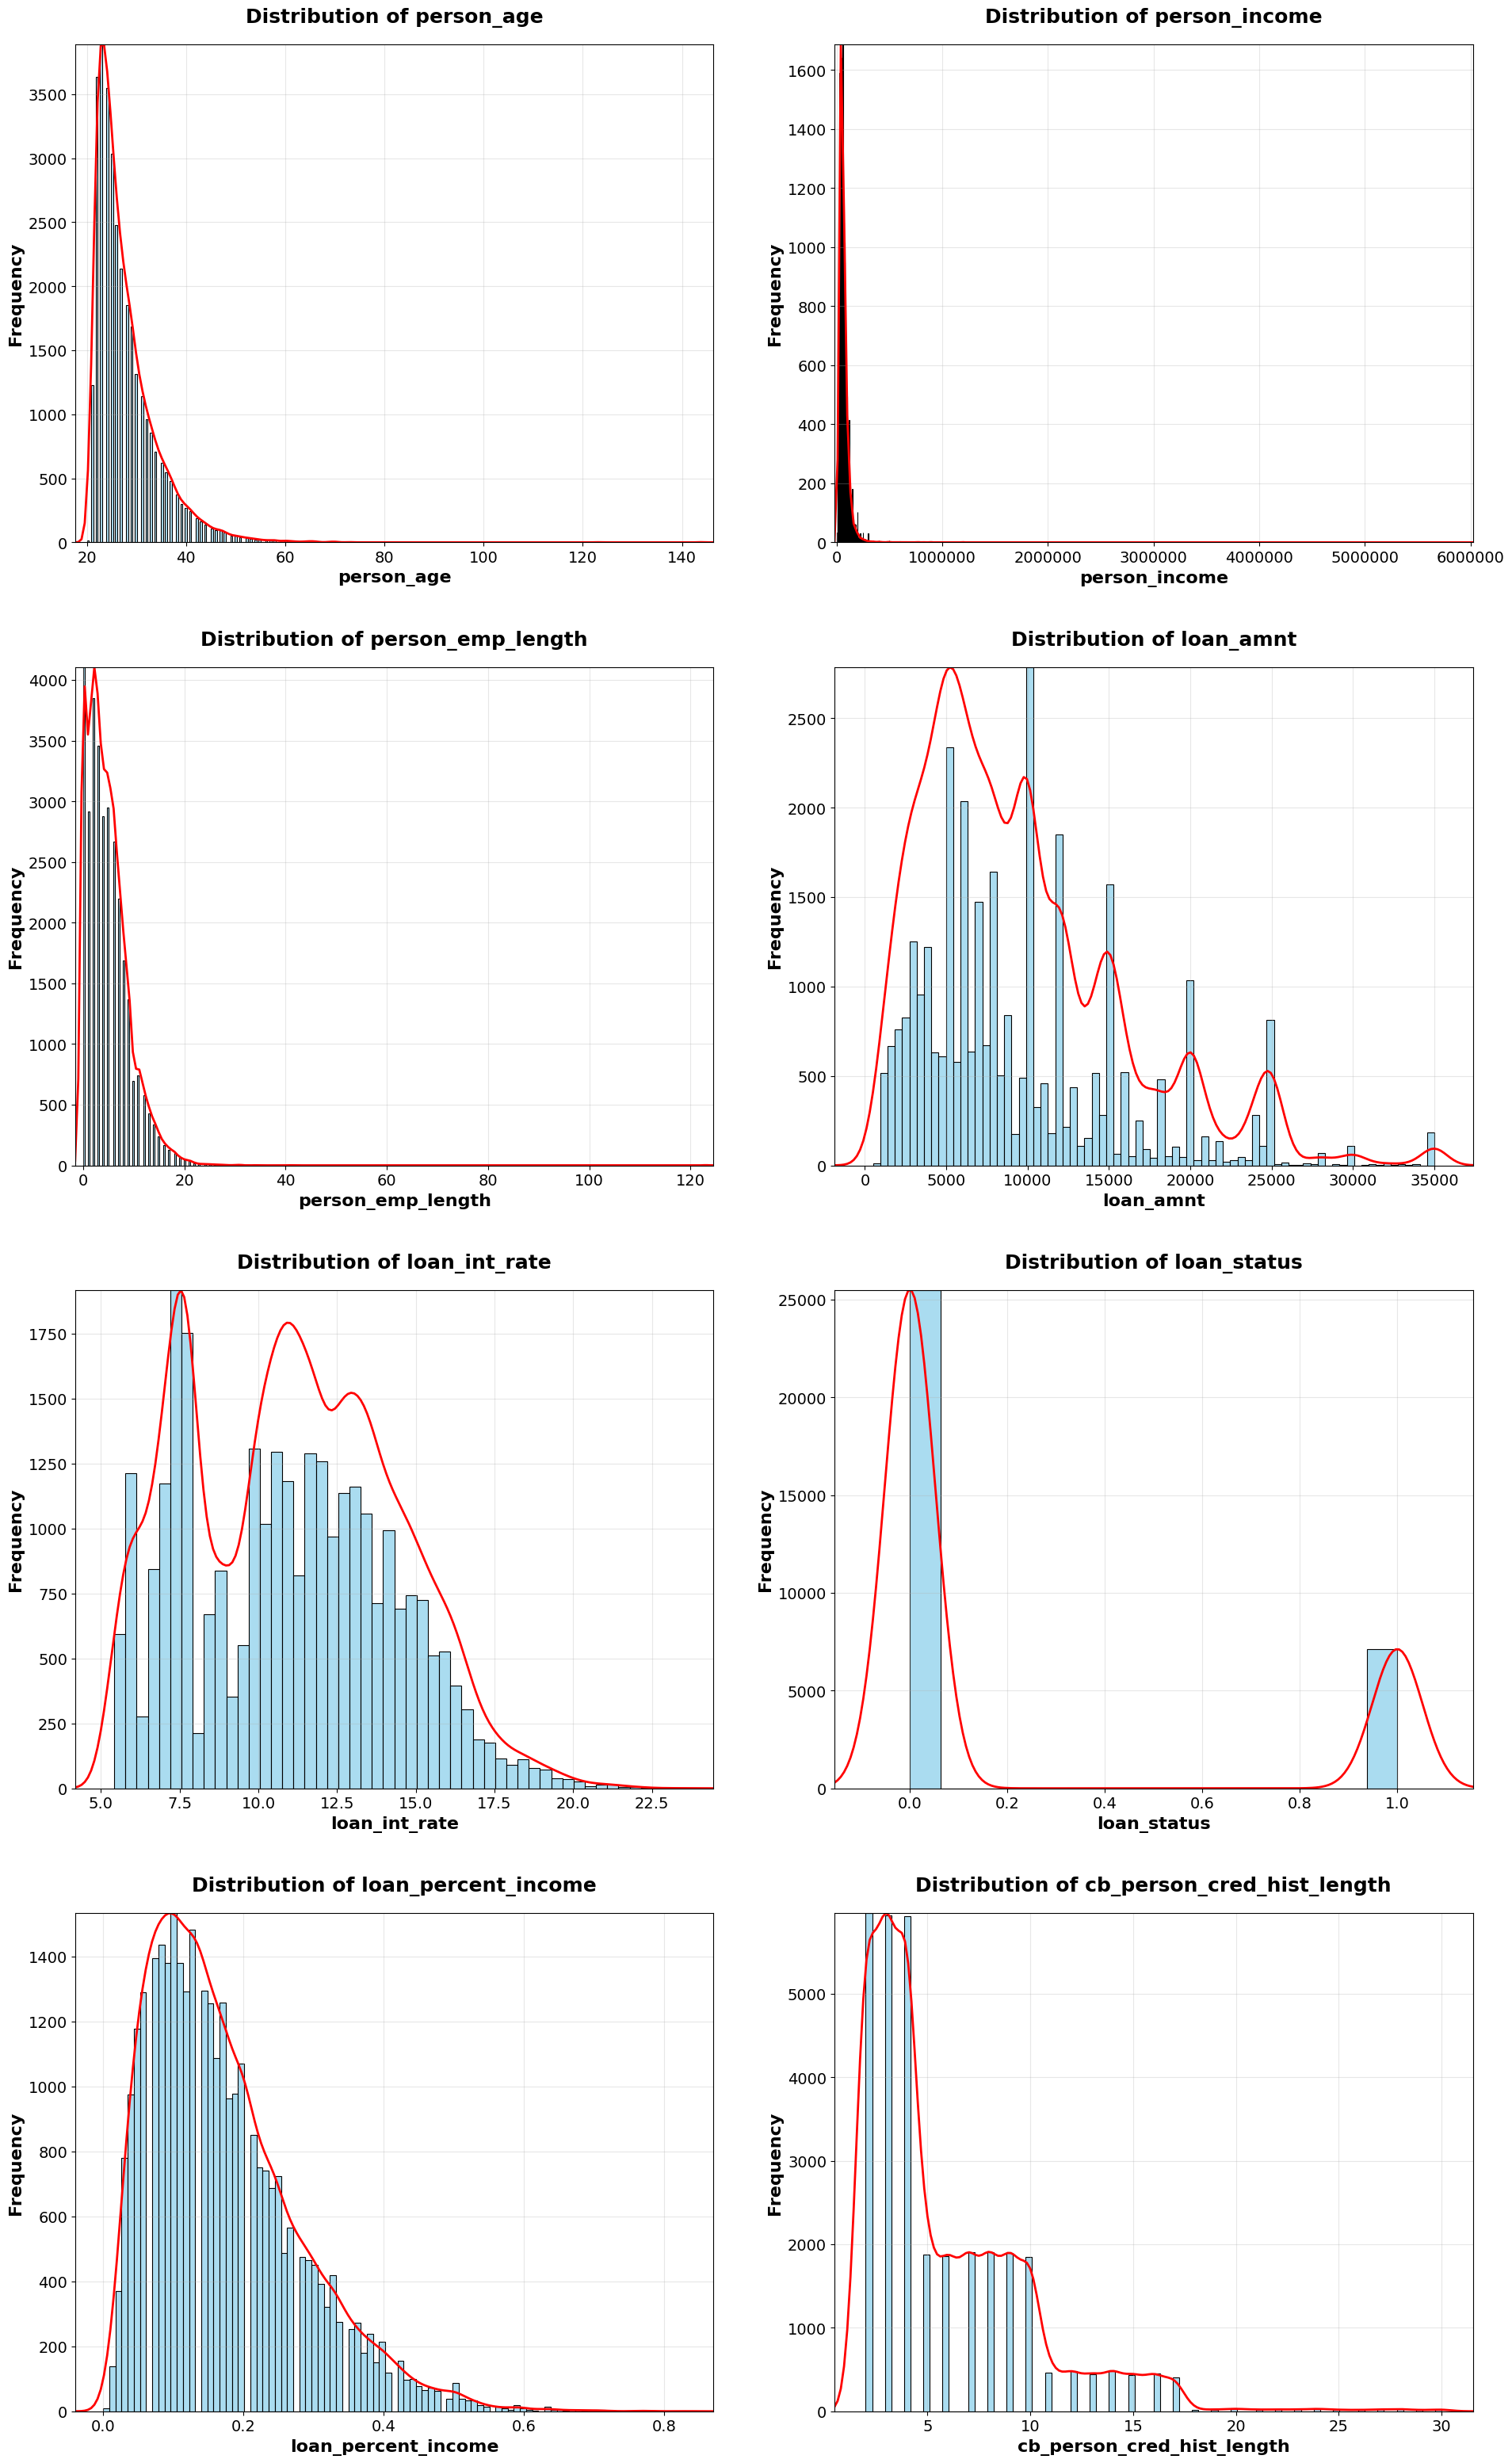

In [19]:
kde_color = 'red'                                              # Set the distribution line color
# Select only numeric columns
numeric_cols = df_num.columns


# Set up the subplot grid
n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Create figure and axes with appropriate size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8*n_rows))

# If only one row, axes might not be 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Plot frequency histogram for each numeric column
for i, column in enumerate(numeric_cols):
    # Plot histogram with frequency (count)
    ax = sns.histplot(df_num[column], kde=False, stat='count', alpha=0.7,
                      edgecolor='black', linewidth=0.8, ax=axes_flat[i],
                      color='skyblue')

    # Add KDE with custom color and scale it to match frequency
    kde = sns.kdeplot(df_num[column], color=kde_color, linewidth=2, ax=ax)

    # Get the KDE line data
    line = ax.lines[0]
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    # Scale the KDE to match the histogram
    hist_data = ax.containers[0].datavalues
    max_hist = max(hist_data) if len(hist_data) > 0 else 1
    max_kde = max(y_data) if len(y_data) > 0 else 1
    scaling_factor = max_hist / max_kde

    # Remove the original KDE line
    ax.lines[0].remove()

    # Plot the scaled KDE
    ax.plot(x_data, y_data * scaling_factor, color=kde_color, linewidth=2)

    # Customize the plot
    axes_flat[i].set_title(f'Distribution of {column}', fontsize=18, fontweight='bold', pad=20)
    axes_flat[i].set_xlabel(column, fontsize=16, fontweight='bold')
    axes_flat[i].set_ylabel('Frequency', fontsize=16, fontweight='bold')
    axes_flat[i].tick_params(axis='both', which='major', labelsize=14)
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].ticklabel_format(style='plain', axis='x')
    axes_flat[i].autoscale(enable=True, axis='both', tight=True)

# Hide any unused subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Adjust layout with more padding
plt.tight_layout(pad=4.0)

plt.show()
plt.close()


In [20]:
# Display the skewness of the dataset
df_num.skew()

,0
person_age,2.581393
person_income,32.865349
person_emp_length,2.614455
loan_amnt,1.192477
loan_int_rate,0.208550
loan_status,1.364888
loan_percent_income,1.064669
cb_person_cred_hist_length,1.661790


In [21]:
# Display the kurtosis of the dataset
df_num.kurtosis()

,0
person_age,18.560825
person_income,2693.272776
person_emp_length,43.722338
loan_amnt,1.423565
loan_int_rate,-0.671609
loan_status,-0.137088
loan_percent_income,1.223687
cb_person_cred_hist_length,3.716194


#### **Bi-Variate Analysis -Numerical-Categorical:**

Bar 0 (D): 63663.68
Bar 1 (B): 66354.84
Bar 2 (C): 64921.94
Bar 3 (A): 66568.21
Bar 4 (E): 70873.11
Bar 5 (F): 77008.73
Bar 6 (G): 76773.30


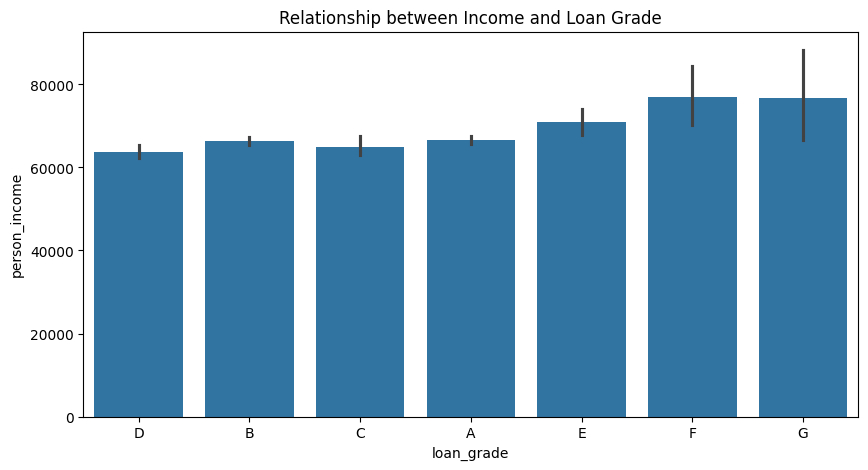

In [22]:
# Relation between person income and loan grade
# Create plot and capture the object
plt.figure(figsize=(10,5))

plt.title("Relationship between Income and Loan Grade")

ax = sns.barplot(x=df_copy["loan_grade"], y=df_copy["person_income"])

# Extract the exact bar heights
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    print(f"Bar {i} ({ax.get_xticklabels()[i].get_text()}): {height:.2f}")

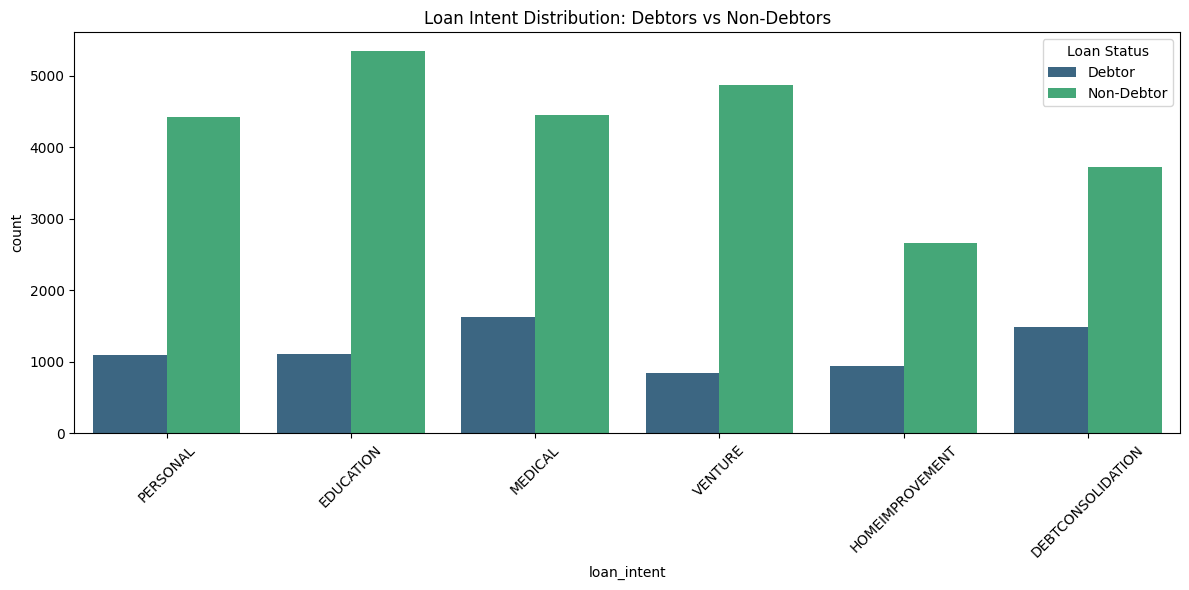

In [23]:
# What type of loan is most defaulted and most not-defaulted.
# Combine both groups and create a new status column
base_credit_comparison = df_copy.copy()
base_credit_comparison['status'] = base_credit_comparison['loan_status'].map({1: 'Debtor', 0: 'Non-Debtor'})

# Create single comparison plot
plt.figure(figsize=(12, 6))
sns.countplot(data=base_credit_comparison, x='loan_intent', hue='status', palette='viridis')
plt.title('Loan Intent Distribution: Debtors vs Non-Debtors')
plt.xticks(rotation=45)
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

### **Decision Tree:**

#### **Pre-processing:**



1.   **<u>Data Manipulation</u>**
      * Handling missing values
      * Removing duplicate rows
      * Removing outliers
2.   **<u>Encoding Techniques</u>**
      *   Label encoding

3.   **<u>Splitting Data</u>**
      * Separate Target and predictors


In [24]:
#Filling the missing values with column median
df_copy.fillna(df_num.median(),inplace = True)

In [25]:
# Remove duplicate rows
df_copy.drop_duplicates(inplace = True,keep='first')

In [26]:
# Removing Outlier from person_age column
# Reasonable age range for loan applicants
min_reasonable_age = 18   # Minimum age for legal contracts
max_reasonable_age = 100  # Maximum reasonable age

print(f"Business Logic Age Limits:")
print(f"Minimum age: {min_reasonable_age}")
print(f"Maximum age: {max_reasonable_age}")

# Find current min/max
current_min = df_copy["person_age"].min()
current_max = df_copy["person_age"].max()
print(f"Current age range: {current_min} to {current_max}")

# Remove outliers
df_clean = df_copy[(df_copy["person_age"] >= min_reasonable_age) & (df_copy["person_age"] <= max_reasonable_age)]

outliers_removed = len(df_copy) - len(df_clean)
print(f"Removed {outliers_removed} age outliers ({outliers_removed/len(df_num)*100:.2f}%)")

# Show what was removed
removed_ages = df_copy[~df_copy.index.isin(df_clean.index)]["person_age"].unique()
print(f"Removed ages: {sorted(removed_ages)}")

# Show the new age range
print(f"New age range: {df_clean['person_age'].min()} to {df_clean['person_age'].max()}")

Business Logic Age Limits:
Minimum age: 18
Maximum age: 100
Current age range: 20 to 144
Removed 5 age outliers (0.02%)
Removed ages: [np.int64(123), np.int64(144)]
New age range: 20 to 94


In [27]:
df_copy = df_clean.copy(deep=True)

In [28]:
# Remove outliers from person_emp_length using business logic
min_reasonable_emp_length = 0   # Minimum employment length (can be 0 for unemployed)
max_reasonable_emp_length = 50  # Maximum reasonable employment length

print(f"Business Logic Employment Length Limits:")
print(f"Minimum employment length: {min_reasonable_emp_length}")
print(f"Maximum employment length: {max_reasonable_emp_length}")

# Find current statistics for employment length
current_emp_min = df_copy["person_emp_length"].min()
current_emp_max = df_copy["person_emp_length"].max()
current_emp_mean = df_copy["person_emp_length"].mean()
current_emp_median = df_copy["person_emp_length"].median()

print(f"\nCurrent Employment Length Statistics:")
print(f"Range: {current_emp_min} to {current_emp_max} years")
print(f"Mean: {current_emp_mean:.2f} years")
print(f"Median: {current_emp_median:.2f} years")

# Identify outliers before removal
emp_outliers = df_copy[(df_copy["person_emp_length"] < min_reasonable_emp_length) | (df_copy["person_emp_length"] > max_reasonable_emp_length)]

print(f"\nOutlier Analysis:")
print(f"Found {len(emp_outliers)} employment length outliers")
if len(emp_outliers) > 0:
    print(f"Outlier employment lengths: {sorted(emp_outliers['person_emp_length'].unique())}")
    print(f"Outlier range: {emp_outliers['person_emp_length'].min()} to {emp_outliers['person_emp_length'].max()} years")

# Store count before employment length removal
before_emp_removal_count = len(df_copy)

# Remove employment length outliers by updating df_copy directly
df_copy = df_copy[(df_copy["person_emp_length"] >= min_reasonable_emp_length) & (df_copy["person_emp_length"] <= max_reasonable_emp_length)]

# Calculate employment length removal results
emp_outliers_removed = before_emp_removal_count - len(df_copy)
emp_percentage_removed = (emp_outliers_removed / before_emp_removal_count) * 100

print(f"\n✅ Employment Length Removal Results:")
print(f"Before removal: {before_emp_removal_count:,} rows")
print(f"Updated df_copy: {len(df_copy):,} rows")
print(f"Rows removed: {emp_outliers_removed:,} ({emp_percentage_removed:.2f}%)")
print(f"New employment length range: {df_copy['person_emp_length'].min()} to {df_copy['person_emp_length'].max()} years")

# Show new employment length statistics
print(f"\n📊 New Employment Length Statistics:")
print(f"Mean: {df_copy['person_emp_length'].mean():.2f} years")
print(f"Median: {df_copy['person_emp_length'].median():.2f} years")
print(f"Standard Deviation: {df_copy['person_emp_length'].std():.2f} years")

Business Logic Employment Length Limits:
Minimum employment length: 0
Maximum employment length: 50

Current Employment Length Statistics:
Range: 0.0 to 123.0 years
Mean: 4.77 years
Median: 4.00 years

Outlier Analysis:
Found 2 employment length outliers
Outlier employment lengths: [np.float64(123.0)]
Outlier range: 123.0 to 123.0 years

✅ Employment Length Removal Results:
Before removal: 32,411 rows
Updated df_copy: 32,409 rows
Rows removed: 2 (0.01%)
New employment length range: 0.0 to 41.0 years

📊 New Employment Length Statistics:
Mean: 4.76 years
Median: 4.00 years
Standard Deviation: 3.98 years


In [29]:
# Check imbalance after pre-processing
print("Original Class Distribution:")
print(df_copy['loan_status'].value_counts())
print("\nPercentage:")
print((df_copy['loan_status'].value_counts() / len(df) * 100).round(2))

Original Class Distribution:
loan_status
0    25321
1     7088
Name: count, dtype: int64

Percentage:
loan_status
0    77.72
1    21.76
Name: count, dtype: float64


In [30]:
# Before encoding
df_copy.iloc[0]

,1
person_age,21
person_income,9600
person_home_ownership,OWN
person_emp_length,5.0
loan_intent,EDUCATION
loan_grade,B
loan_amnt,1000
loan_int_rate,11.14
loan_status,0
loan_percent_income,0.1


In [31]:
cols = df_copy.select_dtypes(include='O').columns
# let's label encode this features
lenc = LabelEncoder()

# loop over each column with the type 'object' => string
for col in cols:
    # fit_transform
    df_copy[col] = lenc.fit_transform(df_copy[col])



In [32]:
# After encoding
df_copy.iloc[0]

,1
person_age,21.00
person_income,9600.00
person_home_ownership,2.00
person_emp_length,5.00
loan_intent,1.00
loan_grade,1.00
loan_amnt,1000.00
loan_int_rate,11.14
loan_status,0.00
loan_percent_income,0.10


In [33]:
# Splitting data into two parts ( Predictors -> X, Target -> Y)
X = df_copy.drop(columns='loan_status')
Y = df_copy['loan_status']

#### **Model Training:**

*   Train - Test split
*   Training of Decision Tree (Id3)






In [34]:
# Spliting the data into train and test data

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=42)

In [35]:
# Training the id3 model
id3 = DecisionTreeClassifier(criterion = 'entropy', class_weight='balanced', random_state=42)
id3.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

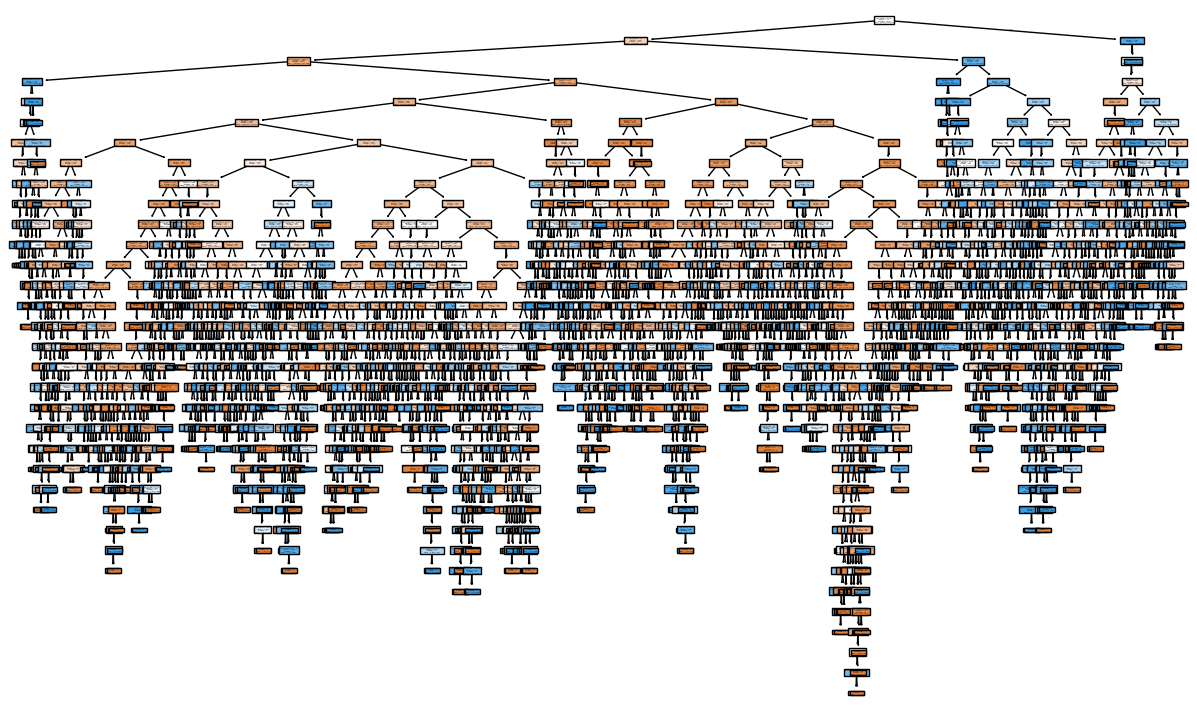

In [36]:
# Plotting the decision tree
plt.figure(figsize=(15, 9))
plot_tree(id3, feature_names=df.columns, filled=True);

In [37]:
# depth of the tree
id3.get_depth()


33

In [38]:
# features importance ✨
importance_id3 = id3.feature_importances_
importance_id3


array([0.04799812, 0.17256914, 0.1000712 , 0.06253975, 0.06984733,
       0.18598017, 0.05246149, 0.07831439, 0.18931868, 0.00567645,
       0.03522327])

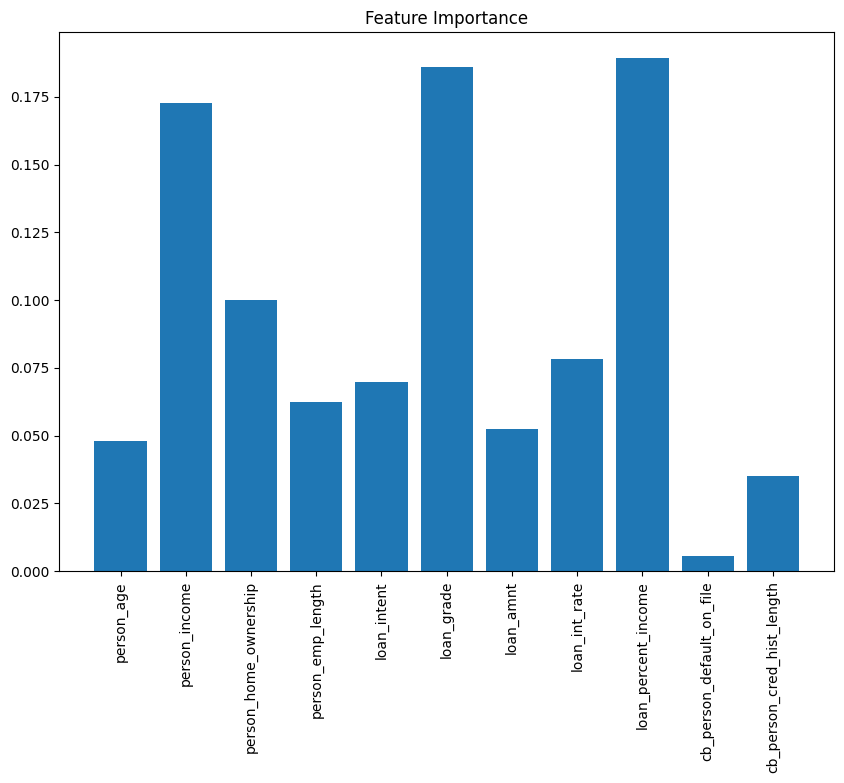

In [39]:
plt.figure(figsize=(10,7))
plt.bar(id3.feature_names_in_, importance_id3)
plt.title('Feature Importance')
plt.xticks(rotation=90);

In [40]:
# getting the score
print(f"Training accuracy : {id3.score(X_train, Y_train)}")
print(f"Test accuracy {id3.score(X_test, Y_test)}")

Training accuracy : 1.0
Test accuracy 0.8901573588398642


#### **Post - Pruning and Re-Training Model:**

In [41]:
# train the decision tree model with post-pruning
path = id3.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
models = []
train_scores = []
test_scores = []
for i, ccp_alpha in enumerate(ccp_alphas):
    model = DecisionTreeClassifier(criterion = 'entropy', class_weight='balanced', random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, Y_train)
    train_scores.append(model.score(X_train, Y_train))
    test_scores.append(model.score(X_test, Y_test))
    print(f"Accuracy with pruning #{i+1}:", model.score(X_test, Y_test))
    models.append(model)

Accuracy with pruning #1: 0.8901573588398642
Accuracy with pruning #2: 0.8901573588398642
Accuracy with pruning #3: 0.8901573588398642
Accuracy with pruning #4: 0.8901573588398642
Accuracy with pruning #5: 0.8901573588398642
Accuracy with pruning #6: 0.8901573588398642
Accuracy with pruning #7: 0.8901573588398642
Accuracy with pruning #8: 0.8901573588398642
Accuracy with pruning #9: 0.8901573588398642
Accuracy with pruning #10: 0.8901573588398642
Accuracy with pruning #11: 0.8901573588398642
Accuracy with pruning #12: 0.8901573588398642
Accuracy with pruning #13: 0.8901573588398642
Accuracy with pruning #14: 0.8901573588398642
Accuracy with pruning #15: 0.8901573588398642
Accuracy with pruning #16: 0.8901573588398642
Accuracy with pruning #17: 0.8901573588398642
Accuracy with pruning #18: 0.8901573588398642
Accuracy with pruning #19: 0.8901573588398642
Accuracy with pruning #20: 0.8901573588398642
Accuracy with pruning #21: 0.8901573588398642
Accuracy with pruning #22: 0.89015735883986

In [42]:
# Checking the shape
print("len(ccp_alphas):", len(ccp_alphas))
print("len(train_scores):", len(train_scores))
print("len(test_scores):", len(test_scores))

len(ccp_alphas): 1257
len(train_scores): 1257
len(test_scores): 1257


Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

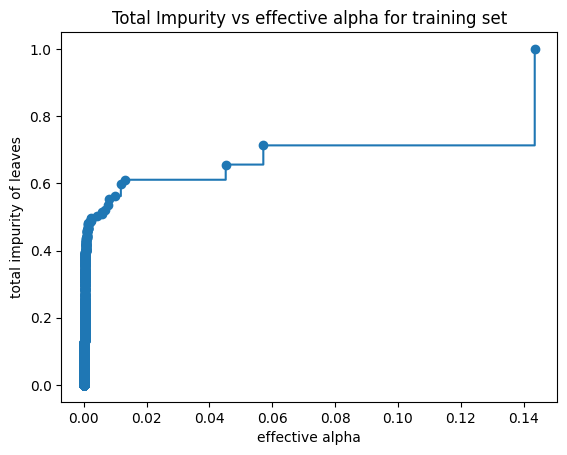

In [43]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

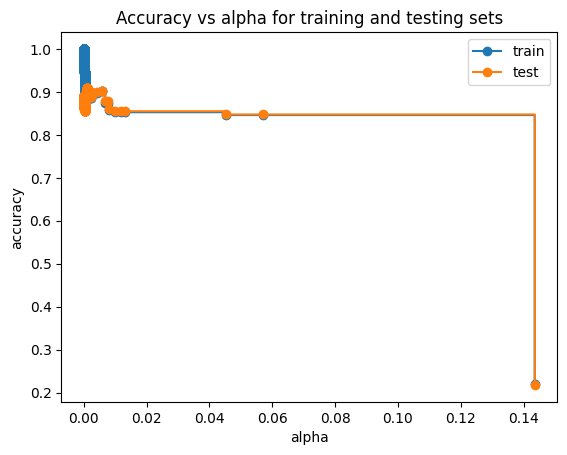

In [44]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [45]:
# Re Training the model with ccp_alpha value
id3_2 = DecisionTreeClassifier(criterion = 'entropy', class_weight='balanced', ccp_alpha = 0.004, random_state = 42)

# fitting the model
id3_2.fit(X_train, Y_train)

# train acc, test acc
id3_2.score(X_train, Y_train), id3_2.score(X_test, Y_test)

(0.8969849246231156, 0.8999280057595392)

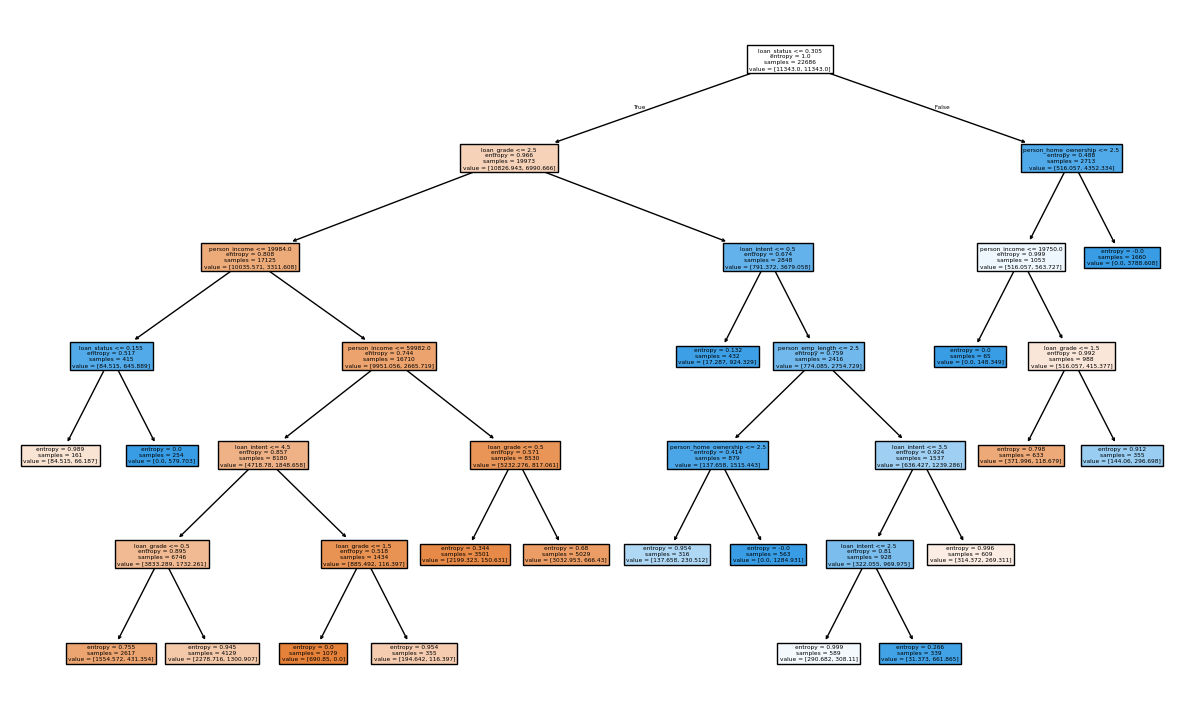

In [46]:
# Plotting the decision tree
plt.figure(figsize=(15, 9))
plot_tree(id3_2, feature_names=df.columns, filled=True);

#### **Model Evaluation:**

In [47]:
# accuracy report
Y_pred = id3_2.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7605
           1       0.80      0.72      0.76      2118

    accuracy                           0.90      9723
   macro avg       0.86      0.84      0.85      9723
weighted avg       0.90      0.90      0.90      9723



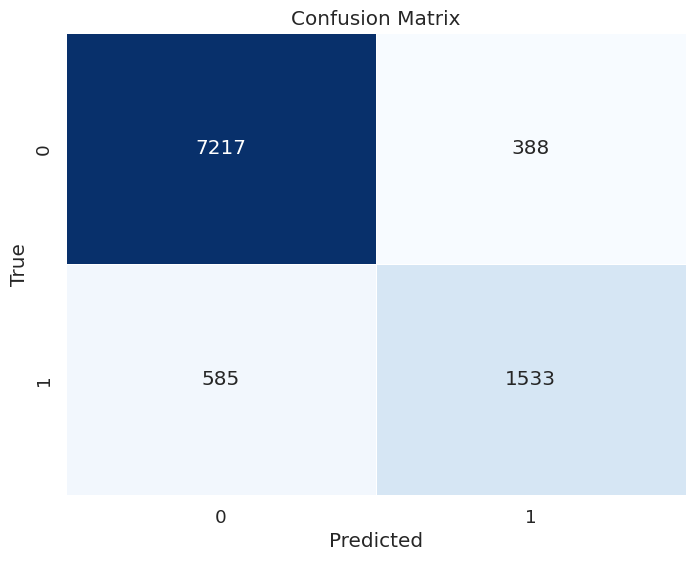

In [48]:
conf_matrix = confusion_matrix(Y_test, Y_pred)


plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust the font size as needed
sns.heatmap(conf_matrix, annot=True, fmt="d", linewidths=0.5, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()